In [1]:
import sys

sys.path.append("../../..")

import importlib, NB_config

importlib.reload(NB_config)
from NB_config import *

In [2]:
df = pd.read_csv(DATASET_PATH, low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 149,485 rows × 59 columns


,business_id,name,city,country,country_name,continent,latitude,longitude,stars,review_count,...,country_grouped_JP,country_grouped_KR,country_grouped_MY,country_grouped_NL,country_grouped_PT,country_grouped_TH,country_grouped_TW,country_grouped_US,country_grouped_ZA,country_grouped_other
0,680ac5b42a0f865f,Trèsind Studio,Dubai,AE,United Arab Emirates,Asia,25.114932,55.139118,3.050171,83,...,False,False,False,False,False,False,False,False,False,True
1,fb5f7e0a9343ae29,Atrevo,Porto,PT,Portugal,Europe,41.146694,-8.601363,2.857886,16,...,False,False,False,False,True,False,False,False,False,False
2,2ca10f4418f15849,Chocho,Paris,FR,France,Europe,48.875729,2.348994,3.020903,38,...,False,False,False,False,False,False,False,False,False,False


In [3]:
df_cats = df[["name", "entity_type", "stars", "categories_clean"]].copy()
df_cats = df_cats[df_cats["categories_clean"].notna() & (df_cats["categories_clean"] != "")]
df_cats = df_cats.rename(columns={"categories_clean": "category"})

print(f"Unique categories: {df_cats['category'].nunique():,}")
df_cats.head(5)

Unique categories: 1,780


,name,entity_type,stars,category
0,Trèsind Studio,restaurant,3.050171,indian
1,Atrevo,restaurant,2.857886,contemporary
2,Chocho,restaurant,3.020903,"creative, modern cuisine"
3,Bonhomme,restaurant,3.071317,modern cuisine
4,Braise,restaurant,2.963668,modern cuisine


In [4]:
print(df.columns)

Index(['business_id', 'name', 'city', 'country', 'country_name', 'continent',
       'latitude', 'longitude', 'stars', 'review_count', 'address',
       'description', 'source', 'entity_type', 'popularity', 'attr_wheelchair',
       'attr_fee', 'attr_internet_access', 'attr_smoking',
       'attr_air_conditioning', 'attr_takeaway', 'attr_capacity',
       'attr_delivery', 'attr_outdoor_seating', 'attr_diet_vegetarian',
       'attr_diet_vegan', 'has_any_attributes', 'categories_clean',
       'description_clean', 'desc_len', 'desc_score', 'cat_count', 'cat_score',
       'quality_score', 'stars_norm', 'review_count_norm', 'popularity_norm',
       'missing_description', 'missing_location', 'country_grouped_AU',
       'country_grouped_CA', 'country_grouped_DE', 'country_grouped_ES',
       'country_grouped_FR', 'country_grouped_GB', 'country_grouped_HK',
       'country_grouped_ID', 'country_grouped_IN', 'country_grouped_IT',
       'country_grouped_JP', 'country_grouped_KR', 'country_

In [5]:
top_cats = df_cats["category"].value_counts().head(10)
fig = px.bar(
    x=top_cats.values,
    y=top_cats.index,
    orientation="h",
    title="Top 10 Categories (All Entities)",
    labels={"x": "Count", "y": "Category"},
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

In [6]:
for entity in df_cats["entity_type"].dropna().unique():
    subset = df_cats[df_cats["entity_type"] == entity]
    top = subset["category"].value_counts().head(15)

    fig = px.bar(
        x=top.values,
        y=top.index,
        orientation="h",
        title=f"Top 15 Categories — {entity}",
        labels={"x": "Count", "y": "Category"},
        template=PLOTLY_TEMPLATE,
    )
    fig.update_layout(yaxis=dict(autorange="reversed"))
    fig.show()

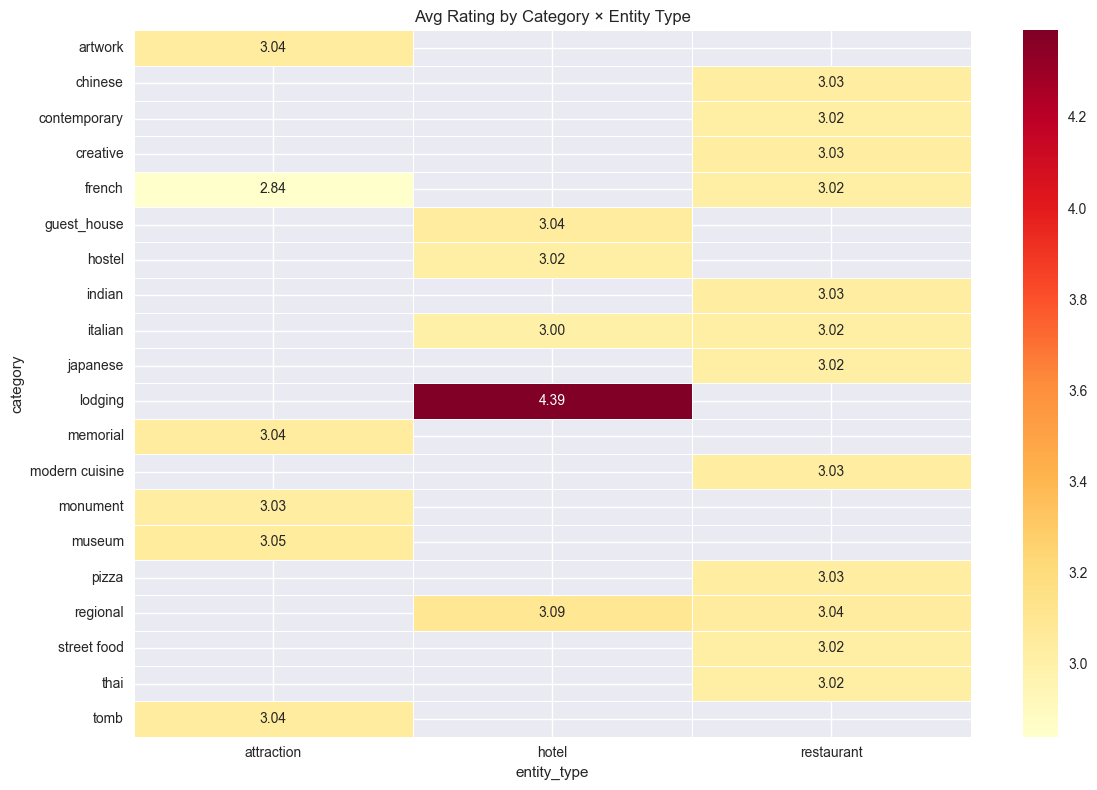

In [7]:
top_20 = df_cats["category"].value_counts().head(20).index

heat_data = (
    df_cats[df_cats["category"].isin(top_20)]
    .groupby(["category", "entity_type"])["stars"]
    .mean()
    .unstack()
    .round(2)
)

plt.figure(figsize=(12, 8))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg Rating by Category × Entity Type")
plt.tight_layout()
plt.show()

In [8]:
counts = df["entity_type"].value_counts()

fig = px.pie(
    values=counts.values,
    names=counts.index,
    title="Entity Type Distribution",
    template=PLOTLY_TEMPLATE,
    hole=0.35,
)
fig.show()

In [9]:
wheelchair_data = df["attr_wheelchair"].value_counts()

fig = px.pie(
    values=wheelchair_data.values,
    names=wheelchair_data.index,
    title="Wheelchair Accessibility (where reported)",
    template=PLOTLY_TEMPLATE,
    hole=0.35,
)
fig.show()

In [10]:
hotels = df[df["entity_type"] == "hotel"]

print(f"Hotels: {len(hotels):,} rows")
print(f"Avg stars       : {hotels['stars'].mean():.2f}")

fig = px.histogram(
    hotels,
    x="stars",
    nbins=20,
    title="Hotel Star Rating Distribution",
    template=PLOTLY_TEMPLATE,
)
fig.show()

Hotels: 126,599 rows
Avg stars       : 4.35


In [11]:
fill_candidates = {
    "price_level": "Predictable from categories + stars via regression",
    "description": "Generatable from name + categories via LLM",
    "attributes": "Partially inferable from entity_type + categories",
}

fill_candidates = {k: v for k, v in fill_candidates.items() if k in df.columns}

missing = (
    df[list(fill_candidates.keys())].isnull().sum().rename("missing_count").to_frame()
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(1)
missing["fill_strategy"] = missing.index.map(fill_candidates)

print(missing.to_string())

             missing_count  missing_pct                               fill_strategy
description          30080         20.1  Generatable from name + categories via LLM
